In [1]:
# Biblioteca para operações numéricas
import numpy as np

# Para visualização
import matplotlib.pyplot as plt

# Para redes neurais
import tensorflow as tf

# Interface de alto nível para construir redes neurais
from tensorflow import keras

# Importando as camadas da rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, \
 Flatten, Dense, Dropout

# Funções utilitárias para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array

# Carregar a base de Dados CIFAR-10

In [2]:
# Carregar a base CIFAR
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar os valores para um intervalo [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# y vem como coluna.
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ["avião", "automóvel", "pássaro", "gato", "cervo",
               "cachorro", "sapo", "cavalo", "navio", "caminhão"]

print(f"Formato de X_train: ", X_train.shape)
print(f"Formato de y_train: ", y_train.shape)
print(f"Formato de X_test: ", X_test.shape)
print(f"Formato de y_test: ", y_test.shape)



Formato de X_train:  (50000, 32, 32, 3)
Formato de y_train:  (50000,)
Formato de X_test:  (10000, 32, 32, 3)
Formato de y_test:  (10000,)


Plotar imagens

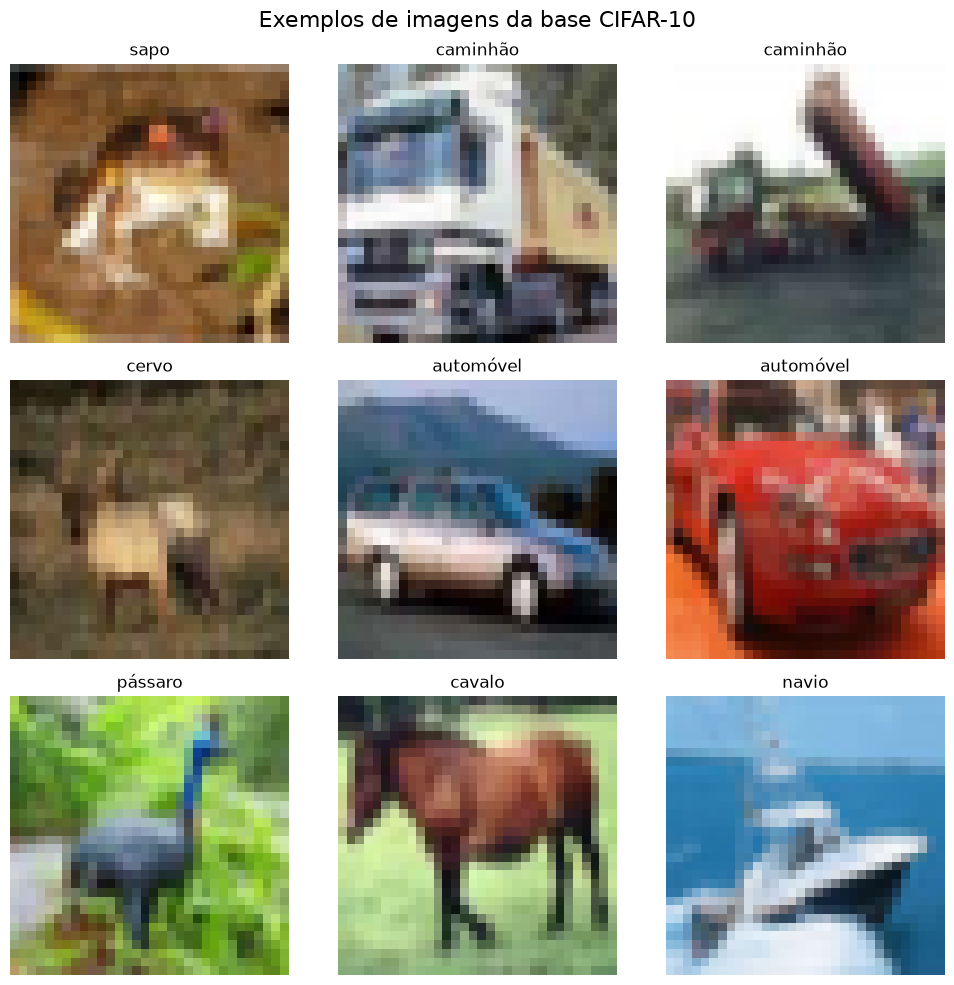

In [3]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Exemplos de imagens da base CIFAR-10", fontsize=16)
plt.tight_layout()
plt.show()

Criação do Modelo CNN

In [4]:
model = keras.Sequential()

# Camada de Entrada
model.add(Input(shape=(32, 32, 3)))

# Bloco 1
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 2
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 3
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Transição CNN => Dense (fully connected)
model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(10, activation='softmax'))

# Compilando o modelo
model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,682 (158.91 KB)

 Trainable params: 40,682 (158.91 KB)

 Non-trainable params: 0 (0.00 B)

Treinando a Rede

In [5]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64,
                    validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.3739 - loss: 1.7063 - val_accuracy: 0.4826 - val_loss: 1.4534
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5108 - loss: 1.3648 - val_accuracy: 0.5439 - val_loss: 1.2842
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.5595 - loss: 1.2460 - val_accuracy: 0.5711 - val_loss: 1.2060
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5890 - loss: 1.1661 - val_accuracy: 0.5898 - val_loss: 1.1647
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.6140 - loss: 1.1005 - val_accuracy: 0.6073 - val_loss: 1.1276
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6331 - loss: 1.0441 - val_accuracy: 0.6222 - val_loss: 1.0770
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6488 - loss: 1.0061 - val_accuracy: 0.6250 - val_loss: 1.0831
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6626 - loss: 0.9623 - 

Métricas

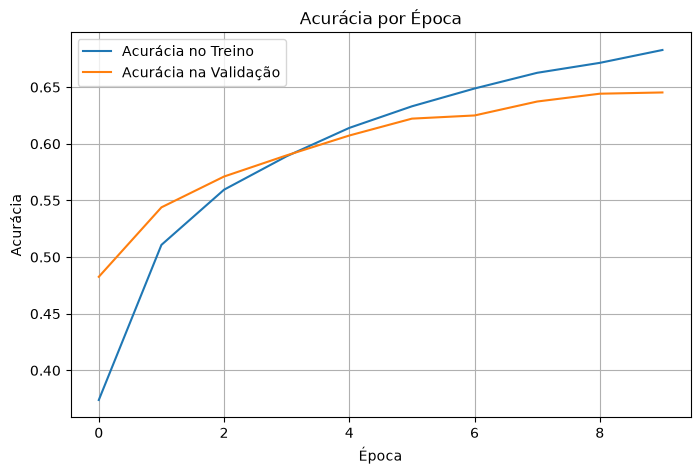

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Acurácia no Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia na Validação')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid() 

Realizando predições

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Acurácia no conjunto de teste: {test_acc:.4f}")
print(f"Loss no conjunto de teste: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6466 - loss: 1.0102
Acurácia no conjunto de teste: 0.6466
Loss no conjunto de teste: 1.0102


Previsões nas imagens de teste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step


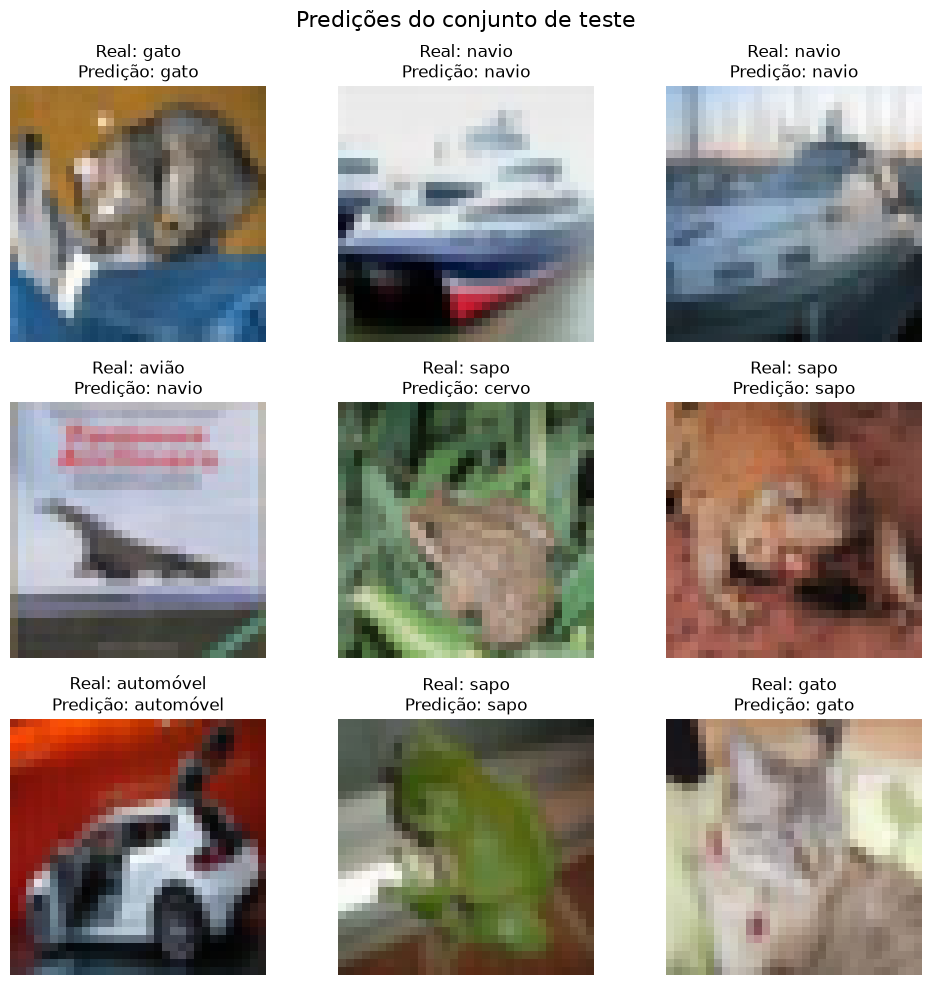

In [8]:
pred_probs = model.predict(X_test[:9])
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i])
    real = class_names[y_test[i]]
    pred = class_names[pred_labels[i]]
    plt.title(f"Real: {real}\nPredição: {pred}")
    plt.axis("off")

plt.suptitle("Predições do conjunto de teste", fontsize=16)
plt.tight_layout()
plt.show()

Matriz de confusão

In [9]:
# Matriz de confusão

